# 🔮 Forecasting de Demanda Eléctrica con InfluxDB

## Resumen

Este notebook implementa un modelo de forecasting sobre la serie temporal de demanda eléctrica española almacenada en InfluxDB.

El objetivo es generar predicciones horarias de consumo eléctrico a corto plazo utilizando datos históricos previamente ingestados desde la API de Red Eléctrica de España (REE).

La solución permite:

- Recuperar series históricas desde InfluxDB.
- Preparar datos para entrenamiento.
- Entrenar modelos de forecasting basados en Random Forest.
- Evaluar el rendimiento predictivo.
- Publicar las predicciones nuevamente en InfluxDB.
- Integrar resultados en dashboards operacionales.

---

## Arquitectura del flujo

```text
                ┌──────────────────────────┐
                │   Ingestion Pipeline     │
                │ (REE / API / Backfill)   │
                └────────────┬─────────────┘
                             │
                             ▼
                ┌──────────────────────────┐
                │     InfluxDB (TSDB)      │
                │  RealDemand + Forecast   │
                └────────────┬─────────────┘
                             │
          ┌──────────────────┴──────────────────┐
          ▼                                     ▼
┌──────────────────────┐           ┌────────────────────────┐
│ Forecasting Service  │           │   Grafana Dashboard    │
│ (Python batch job)   │           │ Real vs Forecast view  │
└──────────────────────┘           └────────────────────────┘
```

---

In [1]:
import os
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

from influxdb_client import InfluxDBClient, Point, WritePrecision

import warnings
warnings.filterwarnings("ignore")

## Conexión a InfluxDB

Las credenciales se obtienen mediante variables de entorno para evitar exponer información sensible en el repositorio.

Variables requeridas:

- `INFLUX_TOKEN`
- `INFLUX_ORG`
- `INFLUX_BUCKET`
- `INFLUX_URL`

---

In [2]:
from dotenv import load_dotenv

load_dotenv()

client = InfluxDBClient(
    url=os.getenv("INFLUX_URL"),
    token=os.getenv("INFLUX_TOKEN"),
    org=os.getenv("INFLUX_ORG")
)

bucket = os.getenv("INFLUX_BUCKET")
org = os.getenv("INFLUX_ORG")

## Carga de datos históricos

Se recupera la serie temporal de demanda eléctrica real almacenada en InfluxDB.

---

In [3]:
def load_demand_data(client, bucket, org) -> pd.DataFrame:
    query = f'''
    from(bucket: "{bucket}")
      |> range(start: 0)
      |> filter(fn: (r) => r["_measurement"] == "demand")
      |> filter(fn: (r) => r["_field"] == "RealDemand")
      |> keep(columns: ["_time", "_value"])
    '''

    df = client.query_api().query_data_frame(query=query, org=org)

    if df.empty:
        raise ValueError("No data found in InfluxDB")

    df = df[["_time", "_value"]].copy()

    df["datetime"] = pd.to_datetime(df["_time"]).dt.tz_localize(None)

    df = (
        df[["datetime", "_value"]]
        .rename(columns={"_value": "RealDemand"})
        .drop_duplicates()
        .sort_values("datetime")
        .set_index("datetime")
    )

    return df

## Entrenamiento del modelo

Se utiliza Random Forest para modelar la estacionalidad diaria y anual presente en la demanda eléctrica.

El modelo genera predicciones horarias para el día posterior al histórico disponible.

---

In [4]:
def prepare_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    if "RealDemand" not in df.columns:
        raise ValueError("Missing RealDemand column")

    return df

In [5]:
def train_model(df: pd.DataFrame, target_col="RealDemand"):

    df = df[[target_col]].dropna()

    df["lag_1"] = df[target_col].shift(1)
    df["lag_24"] = df[target_col].shift(24)

    df = df.dropna()

    X = df[["lag_1", "lag_24"]]
    y = df[target_col]

    split = int(len(df) * 0.8)

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )

    model.fit(X.iloc[:split], y.iloc[:split])

    return model

In [6]:
def forecast(model, df: pd.DataFrame, steps=24, target_col="RealDemand"):

    history = df.copy()
    preds = []

    for _ in range(steps):

        last = history[target_col].iloc[-1]
        lag_24 = history[target_col].iloc[-24] if len(history) >= 24 else last

        X = np.array([[last, lag_24]])
        pred = model.predict(X)[0]

        next_time = history.index[-1] + pd.Timedelta(hours=1)

        history.loc[next_time] = pred
        preds.append((next_time, pred))

    return pd.DataFrame(preds, columns=["datetime", "forecast"]).set_index("datetime")

## Evaluación del modelo

Para medir el rendimiento del sistema se calcula el Error Absoluto Medio (MAE) sobre varios días de validación.

---

In [7]:
def evaluate_model(df: pd.DataFrame, window=24, n_windows=7):

    maes = []

    for i in range(n_windows):

        train = df.iloc[:-(n_windows - i) * window]
        test = df.iloc[-(n_windows - i) * window:
                       -((n_windows - i - 1) * window) if i < n_windows - 1 else None]

        model = train_model(train)
        pred = forecast(model, train, steps=len(test))

        mae = mean_absolute_error(test["RealDemand"], pred["forecast"])
        maes.append(mae)

    return maes

## Publicación de predicciones en InfluxDB

Las predicciones generadas se almacenan en el mismo measurement utilizado para la demanda real.

Nuevo campo:

- `ForecastDemand`

Esto permite comparar en tiempo real:

- Demanda real
- Pronóstico oficial de REE
- Pronóstico generado por el modelo

---

In [8]:
def write_forecast_to_influx(
    forecast_df,
    client,
    bucket,
    org,
    value_col="forecast"
):

    write_api = client.write_api()

    points = []

    for ts, row in forecast_df.iterrows():

        points.append(
            Point("demand")
            .field("ForecastDemand", float(row[value_col]))
            .time(ts, WritePrecision.NS)
        )

    write_api.write(bucket=bucket, org=org, record=points)

## Pipeline principal (BACKFILL / RUN)

In [9]:
df = load_demand_data(client, bucket, org)

### Exploración inicial

Antes de entrenar el modelo se verifica la calidad y continuidad de la serie temporal.


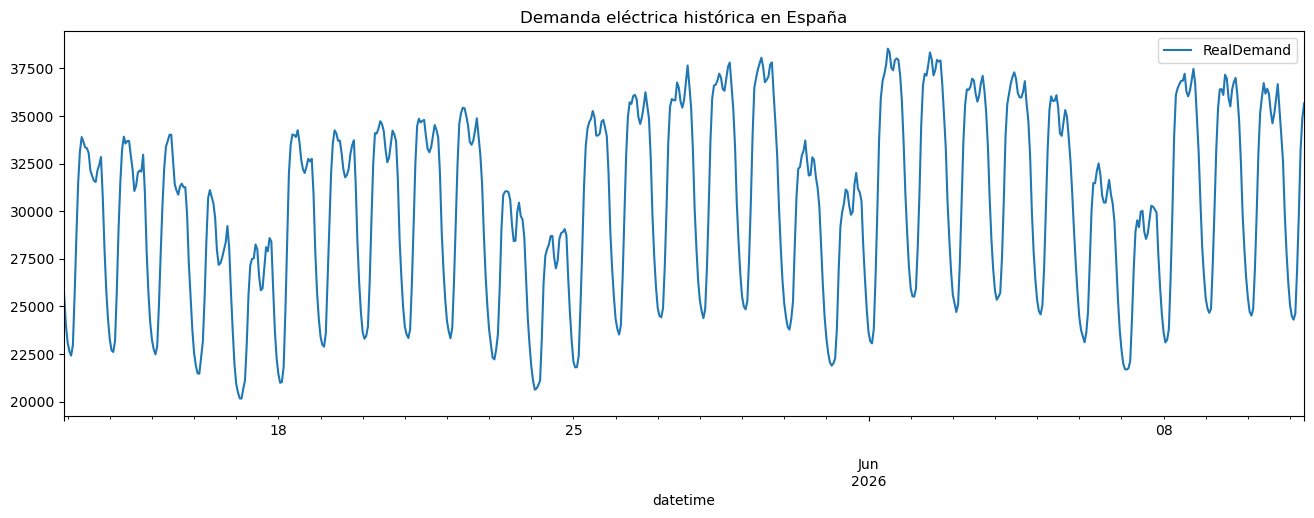

In [10]:
df.plot(
    figsize=(16,5),
    title="Demanda eléctrica histórica en España"
)
plt.show()

In [11]:
df = prepare_data(df)

model = train_model(df)

forecast_24h = forecast(model, df, steps=24)

write_forecast_to_influx(
    forecast_24h,
    client,
    bucket,
    org
)

print("Forecast generado y almacenado en InfluxDB")

Forecast generado y almacenado en InfluxDB


## Evaluación del modelo

In [12]:
maes = evaluate_model(df)

print("MAE por ventana:", maes)
print("MAE medio:", np.mean(maes))

MAE por ventana: [1164.0604374999934, 2464.5329999999735, 2886.3828749999957, 2301.311875000005, 2517.9383333333394, 2836.062333333322, 3350.1174166666824]
MAE medio: 2502.9151815476157


# Conclusiones

Este notebook amplía la arquitectura de datos desarrollada en la fase de ingesta incorporando capacidades de forecasting sobre series temporales energéticas.

Resultados obtenidos:

- Recuperación de histórico desde InfluxDB.
- Entrenamiento de un modelo Random Forest para forecasting horario.
- Generación de predicciones horarias.
- Publicación de resultados en InfluxDB.
- Integración con dashboards para monitorización.

La solución permite evolucionar hacia escenarios más avanzados de analítica predictiva, detección de anomalías y optimización energética.

---